# Predator–Prey Modelling (CITS4403 Project)

**Authors:** Su-Yeon Yang, Jiaren Zhu
**Date:** 2025-10-01

## Model Overview and Assumptions
This project includes two complementary modeling approaches:

1. **ODE Baseline (Lotka–Volterra):** Represents well-mixed predator–prey interactions without spatial structure. Used solely for comparison.
2. **Spatial ABM (Toroidal Grid):**
- Each grid cell can contain at most one agent (prey or predator).
- **Prey:** move randomly, reproduce with a given probability, and die if eaten.
- **Predators:** move, consume prey to gain energy, reproduce after successful hunts, and die if their energy drops to zero.
- **Innovation 1 – Spatial Heterogeneity (Refugia):** Some cells are refugia where predators’ hunting success is reduced; prey prefer moving into refugia.
- **Innovation 2 – Adaptive Prey Behavior:** When recent local predation events are high, prey temporarily increase their movement radius from 1 to 2.

**Metrics**
- Time series of predator and prey population sizes.
- Extinction probability across repeated runs.
- Mean ± 95% CI for population trajectories.

## ODE Baseline (Lotka–Volterra)


In [ ]:
import sys, os
sys.path.append('../')
from src import *
from utils import *

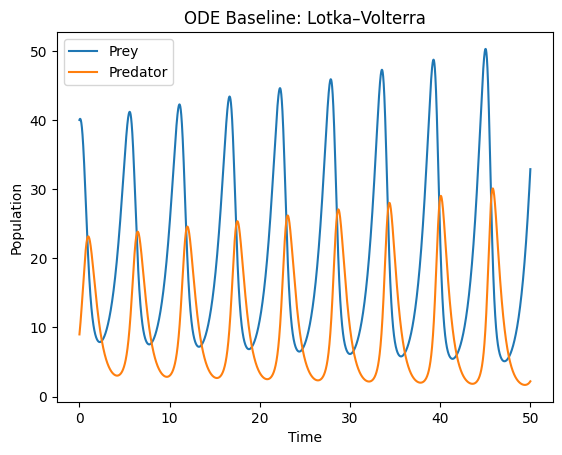

In [3]:
# Smoke test plot
T, X, Y = lotka_volterra()
plt.figure()
plt.plot(T, X, label='Prey')
plt.plot(T, Y, label='Predator')
plt.title('ODE Baseline: Lotka–Volterra')
plt.xlabel('Time'); plt.ylabel('Population')
plt.legend(); plt.show()

## Spatial Agent-Based Model (ABM)

In [4]:
params_no_refugia = ABMParams(refugia_fraction=0.0, adaptive_window=9999)
params_with_innov = ABMParams(refugia_fraction=0.15, adaptive_window=5)

print("Running ABM: no refugia/adapt ...")
prey1, pred1 = replicate_abm(run_abm, params_no_refugia, n_seeds=12)
print("Running ABM: refugia + adaptive ...")
prey2, pred2 = replicate_abm(run_abm, params_with_innov, n_seeds=12)

prey1_m, prey1_lo, prey1_hi = mean_ci(prey1)
pred1_m, pred1_lo, pred1_hi = mean_ci(pred1)
prey2_m, prey2_lo, prey2_hi = mean_ci(prey2)
pred2_m, pred2_lo, pred2_hi = mean_ci(pred2)

print("Done.")

Running ABM: no refugia/adapt ...
Running ABM: refugia + adaptive ...
Done.


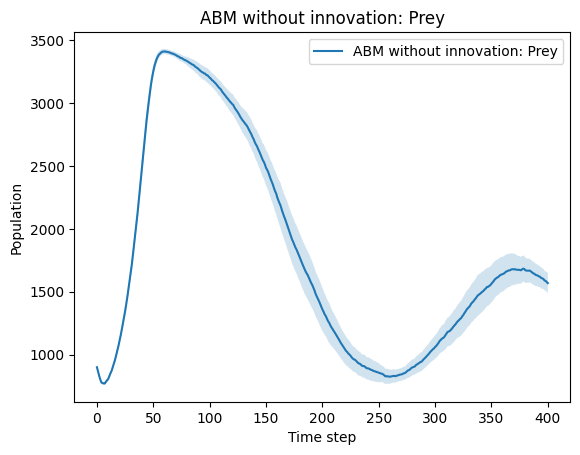

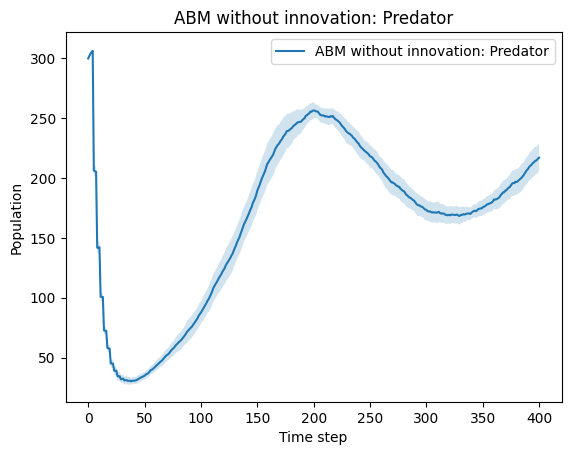

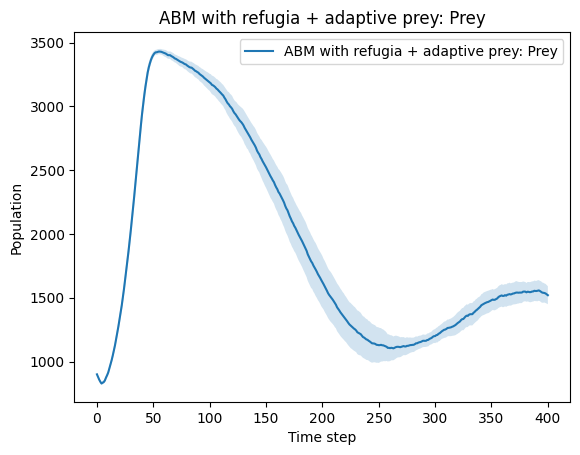

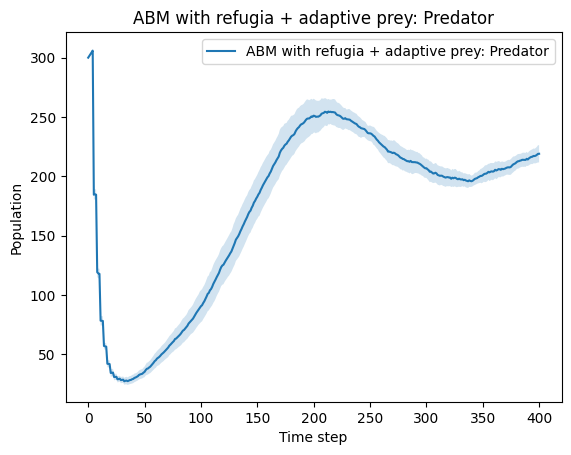

In [5]:
plot_with_ci(prey1_m, prey1_lo, prey1_hi, 'ABM without innovation: Prey')
plot_with_ci(pred1_m, pred1_lo, pred1_hi, 'ABM without innovation: Predator')
plot_with_ci(prey2_m, prey2_lo, prey2_hi, 'ABM with refugia + adaptive prey: Prey')
plot_with_ci(pred2_m, pred2_lo, pred2_hi, 'ABM with refugia + adaptive prey: Predator')

## Extinction Probability

In [6]:
print("Extinction probability (no refugia/adapt):")
print("  Prey:", extinction_prob(prey1))
print("  Pred:", extinction_prob(pred1))
print("Extinction probability (with refugia+adapt):")
print("  Prey:", extinction_prob(prey2))
print("  Pred:", extinction_prob(pred2))

Extinction probability (no refugia/adapt):
  Prey: 0.0
  Pred: 0.0
Extinction probability (with refugia+adapt):
  Prey: 0.0
  Pred: 0.0


Possible reasons: Too dense prey population, Low energy cost to stress predators. No natural prey death, refugia too protective, short simulation.

## ODE vs ABM (Representative Run)

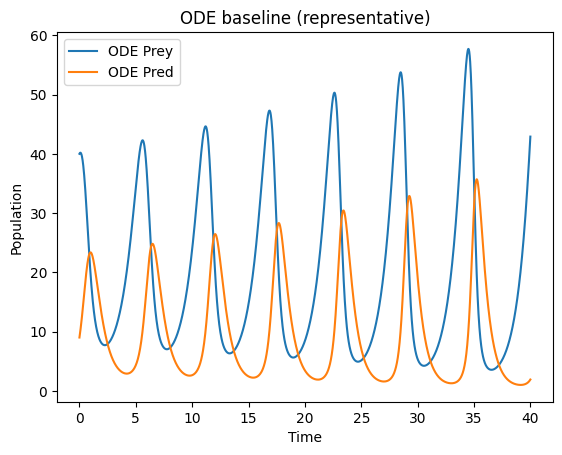

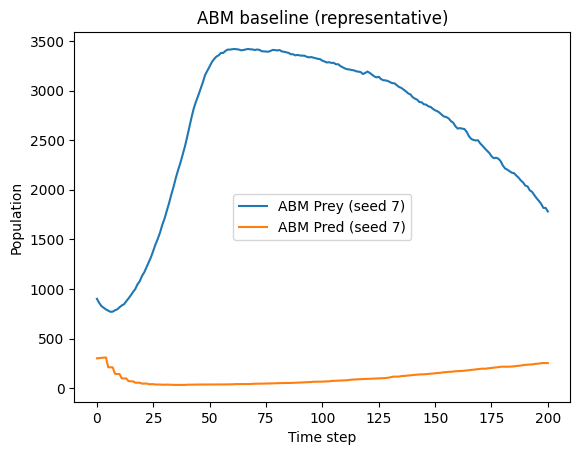

In [7]:
T, X, Y = lotka_volterra(x0=40, y0=9, params=ODEParams(t_end=40, dt=0.02))
P, Q = run_abm(ABMParams(steps=200, refugia_fraction=0.0, adaptive_window=9999), seed=7)

plt.figure()
plt.plot(T, X, label='ODE Prey')
plt.plot(T, Y, label='ODE Pred')
plt.xlabel('Time'); plt.ylabel('Population')
plt.title('ODE baseline (representative)')
plt.legend(); plt.show()

plt.figure()
plt.plot(P, label='ABM Prey (seed 7)')
plt.plot(Q, label='ABM Pred (seed 7)')
plt.xlabel('Time step'); plt.ylabel('Population')
plt.title('ABM baseline (representative)')
plt.legend(); plt.show()

## Reproducibility and Parameters
- All stochastic simulations use fixed seeds; increase `n_seeds` for more robust statistics.
- Core parameters are centralized in the `ABMParams` dataclass.
- Re-running this notebook will regenerate all results and figures.